# BusterNet Validation Diagnostics

Validation-split notebook for Einar's DINO-BusterNet checkpoints. It rebuilds the same validation split, caches prediction probabilities once, reports forged/authentic diagnostics, and plots examples. Do not use the reserved local holdout split here.

In [16]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "einar_busternet").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(PROJECT_ROOT)


/home/einar/projects/INF367A-26V-Recod.ai-LUC-Forgery-Kaggle


## Configuration

`ALLOW_TORCH_HUB` must be `True` before the model is rebuilt. This is intentional because model construction uses official DINO through `torch.hub` and may initialize cached DINO assets.

In [17]:
CHECKPOINT_CHOICE = "last"  # "best", "last", or "custom"
CUSTOM_CHECKPOINT_PATH = None
CHECKPOINT_PATHS = {
    "best": Path("einar_busternet/artifacts/checkpoints/best.pt"),
    "last": Path("einar_busternet/artifacts/checkpoints/last.pt"),
}
CHECKPOINT_PATH = Path(CUSTOM_CHECKPOINT_PATH) if CHECKPOINT_CHOICE == "custom" else CHECKPOINT_PATHS[CHECKPOINT_CHOICE]

DEVICE = "auto"
ALLOW_TORCH_HUB = True
VAL_SUBSET = None
BATCH_SIZE = None
VALIDATION_TRANSFER_MODE = None  # None uses checkpoint config, usually "accumulate_gpu"
THRESHOLD_FOR_TABLES = None      # None uses config.pred_threshold unless USE_BEST_SWEEP_FOR_TABLES is True
USE_BEST_SWEEP_FOR_TABLES = True
TABLE_SWEEP_RANK = 0             # 0 is best row after sorting by kaggle_score

# Exact lightweight sweep from the best settings seen in the wider 32-setting sweep.
CUSTOM_SWEEP_SETTINGS = [
    {"pred_threshold": 0.15, "min_component_area": 10, "apply_opening": False},
    {"pred_threshold": 0.15, "min_component_area": 25, "apply_opening": False},
    {"pred_threshold": 0.15, "min_component_area": 10, "apply_opening": True},
    {"pred_threshold": 0.15, "min_component_area": 0, "apply_opening": True},
    {"pred_threshold": 0.15, "min_component_area": 50, "apply_opening": False},
]

# Fallback product sweep. Used only when CUSTOM_SWEEP_SETTINGS = None.
MAX_SWEEP_SETTINGS = 5
PRED_THRESHOLDS = [0.15, 0.2, 0.25, 0.3]
MIN_COMPONENT_AREAS = [0, 10, 25, 50]
CONFIDENT_THRESHOLDS = None
SMOOTH_OPTIONS = None
OPENING_OPTIONS = [False, True]
CLOSING_OPTIONS = None
FILL_HOLES_OPTIONS = None
KEEP_CONFIDENT_SEEDED_OPTIONS = None



In [18]:
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from dataset_utils import list_labeled_samples
from datasets.splits import make_grouped_stratified_splits
from engine.checkpointing import load_checkpoint
from engine.validation_inference import collect_validation_predictions, score_validation_predictions, _post_process_probability
from engine.validation_records import load_resized_instance_masks
from evaluate_validation_postprocess import iter_postprocess_settings
from einar_busternet.evaluate import (
    _build_val_loader,
    _resolve_device,
    config_from_checkpoint,
    validate_model_loading_allowed,
)
from einar_busternet.model import BusterNetUnionWrapper
from einar_busternet.train import _build_sliding_window_fn, build_model
from inference.postprocess import post_process_prediction
from util.pixelmapUtil import PixelMapUtil
from visualization import ForgeryDataPlotter


## Load Checkpoint And Validation Split

In [19]:
validate_model_loading_allowed(ALLOW_TORCH_HUB)
if CHECKPOINT_CHOICE not in {"best", "last", "custom"}:
    raise ValueError(f"CHECKPOINT_CHOICE must be 'best', 'last', or 'custom', got {CHECKPOINT_CHOICE!r}")
if CHECKPOINT_CHOICE == "custom" and CUSTOM_CHECKPOINT_PATH is None:
    raise ValueError("CUSTOM_CHECKPOINT_PATH must be set when CHECKPOINT_CHOICE='custom'")

device = _resolve_device(DEVICE)
checkpoint = load_checkpoint(CHECKPOINT_PATH, map_location=device, trusted=True)
config = config_from_checkpoint(checkpoint)
if VAL_SUBSET is not None:
    config = type(config)(**{**config.__dict__, "val_subset": VAL_SUBSET})
if BATCH_SIZE is not None:
    config = type(config)(**{**config.__dict__, "batch_size": BATCH_SIZE})
if VALIDATION_TRANSFER_MODE is not None:
    config = type(config)(**{**config.__dict__, "validation_transfer_mode": VALIDATION_TRANSFER_MODE})

all_samples = list_labeled_samples(Path(config.data_root))
splits = make_grouped_stratified_splits(
    all_samples,
    seed=config.seed,
    train_ratio=config.train_ratio,
    val_ratio=config.val_ratio,
    test_ratio=config.test_ratio,
)
val_samples = splits["val"]
if config.val_subset is not None:
    val_samples = val_samples[: config.val_subset]

print(f"device={device}")
print(f"checkpoint_choice={CHECKPOINT_CHOICE}")
print(f"checkpoint={CHECKPOINT_PATH}")
print(f"checkpoint_epoch={checkpoint.get('epoch')}")
print(f"stored_kaggle_score={checkpoint.get('kaggle_score')}")
print(f"validation samples={len(val_samples)}")
print(f"batch_size={config.val_batch_size or config.batch_size}, transfer={config.validation_transfer_mode}")


device=cuda
checkpoint_choice=last
checkpoint=einar_busternet/artifacts/checkpoints/last.pt
checkpoint_epoch=16
stored_kaggle_score=0.5118627250577076
validation samples=514
batch_size=32, transfer=accumulate_gpu


## Cache Validation Predictions

This is the expensive cell. After it runs, the rest of the notebook reuses cached probability maps.

In [20]:
model = build_model(config).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
wrapped_model = BusterNetUnionWrapper(model, eps=config.union_wrapper_eps)

val_loader = _build_val_loader(config, val_samples, device)
predictions = collect_validation_predictions(
    model=wrapped_model,
    val_loader=val_loader,
    val_samples=val_samples,
    device=device,
    inference_mode=config.validation_inference_mode,
    sliding_window_fn=_build_sliding_window_fn(config),
    probability_dtype=config.validation_probability_dtype,
    collect_masks=config.compute_pixel_f1,
    transfer_mode=config.validation_transfer_mode,
)
len(predictions)


Using cache found in /home/einar/.cache/torch/hub/facebookresearch_dinov2_main


514

## Overall Score

In [21]:
pixel_util = PixelMapUtil()
score_result = score_validation_predictions(
    predictions=predictions,
    pixel_util=pixel_util,
    pred_threshold=config.pred_threshold,
    harden_temperature=config.harden_temperature,
    hard_clip_low=config.hard_clip_low,
    hard_clip_high=config.hard_clip_high,
    min_component_area=config.min_component_area,
    compute_pixel_f1=config.compute_pixel_f1,
    verify_score_equivalence=config.verify_score_equivalence,
    confident_threshold=config.post_process_confident_threshold,
    smooth_probabilities=config.post_process_smooth_probabilities,
    fill_holes=config.post_process_fill_holes,
    apply_opening=config.post_process_apply_opening,
    apply_closing=config.post_process_apply_closing,
    keep_confident_seeded_components=config.post_process_keep_confident_seeded_components,
)
score_result


{'kaggle_score': 0.5118627250577076,
 'pixel_f1': None,
 'num_samples': 514,
 'num_forged': 276,
 'num_authentic': 238,
 'postprocess_seconds': 4.90593853000064,
 'scoring_seconds': 0.08761609100019996}

## Focused Post-Processing Sweep

This reuses cached probabilities. By default it runs five exact settings chosen from the best rows of the wider threshold/component/opening sweep. Set `CUSTOM_SWEEP_SETTINGS = None` to fall back to the small product sweep.



In [22]:
def complete_sweep_setting(partial_setting):
    return {
        "pred_threshold": partial_setting.get("pred_threshold", config.pred_threshold),
        "min_component_area": partial_setting.get("min_component_area", config.min_component_area),
        "confident_threshold": partial_setting.get("confident_threshold", config.post_process_confident_threshold),
        "smooth_probabilities": partial_setting.get("smooth_probabilities", config.post_process_smooth_probabilities),
        "apply_opening": partial_setting.get("apply_opening", config.post_process_apply_opening),
        "apply_closing": partial_setting.get("apply_closing", config.post_process_apply_closing),
        "fill_holes": partial_setting.get("fill_holes", config.post_process_fill_holes),
        "keep_confident_seeded_components": partial_setting.get(
            "keep_confident_seeded_components",
            config.post_process_keep_confident_seeded_components,
        ),
        "harden_temperature": config.harden_temperature,
        "hard_clip_low": config.hard_clip_low,
        "hard_clip_high": config.hard_clip_high,
        "compute_pixel_f1": config.compute_pixel_f1,
        "verify_score_equivalence": False,
    }

if CUSTOM_SWEEP_SETTINGS is not None:
    sweep_settings = [complete_sweep_setting(setting) for setting in CUSTOM_SWEEP_SETTINGS]
else:
    sweep_args = SimpleNamespace(
        pred_thresholds=PRED_THRESHOLDS or [config.pred_threshold],
        min_component_areas=MIN_COMPONENT_AREAS or [config.min_component_area],
        confident_thresholds=CONFIDENT_THRESHOLDS or [config.post_process_confident_threshold],
        smooth_options=SMOOTH_OPTIONS or [config.post_process_smooth_probabilities],
        opening_options=OPENING_OPTIONS or [config.post_process_apply_opening],
        closing_options=CLOSING_OPTIONS or [config.post_process_apply_closing],
        fill_holes_options=FILL_HOLES_OPTIONS or [config.post_process_fill_holes],
        keep_confident_seeded_options=KEEP_CONFIDENT_SEEDED_OPTIONS or [config.post_process_keep_confident_seeded_components],
        max_settings=MAX_SWEEP_SETTINGS,
    )
    sweep_settings = iter_postprocess_settings(config, sweep_args)

sweep_rows = []
for rank, setting in enumerate(sweep_settings, start=1):
    result = score_validation_predictions(
        predictions=predictions,
        pixel_util=pixel_util,
        pred_threshold=setting["pred_threshold"],
        harden_temperature=setting["harden_temperature"],
        hard_clip_low=setting["hard_clip_low"],
        hard_clip_high=setting["hard_clip_high"],
        min_component_area=setting["min_component_area"],
        compute_pixel_f1=setting["compute_pixel_f1"],
        verify_score_equivalence=setting["verify_score_equivalence"],
        confident_threshold=setting["confident_threshold"],
        smooth_probabilities=setting["smooth_probabilities"],
        fill_holes=setting["fill_holes"],
        apply_opening=setting["apply_opening"],
        apply_closing=setting["apply_closing"],
        keep_confident_seeded_components=setting["keep_confident_seeded_components"],
    )
    sweep_rows.append({"rank": rank, **setting, **result})

sweep_df = pd.DataFrame(sweep_rows).sort_values("kaggle_score", ascending=False).reset_index(drop=True)
TABLE_POSTPROCESS_SETTING = None
if USE_BEST_SWEEP_FOR_TABLES and len(sweep_df):
    TABLE_POSTPROCESS_SETTING = sweep_df.iloc[TABLE_SWEEP_RANK].to_dict()
    print(
        "Using sweep setting for diagnostic tables:",
        {
            "pred_threshold": TABLE_POSTPROCESS_SETTING["pred_threshold"],
            "min_component_area": TABLE_POSTPROCESS_SETTING["min_component_area"],
            "apply_opening": TABLE_POSTPROCESS_SETTING["apply_opening"],
            "kaggle_score": TABLE_POSTPROCESS_SETTING["kaggle_score"],
        },
    )
sweep_df



Using sweep setting for diagnostic tables: {'pred_threshold': 0.15, 'min_component_area': 50, 'apply_opening': False, 'kaggle_score': 0.515134861838664}


,rank,pred_threshold,min_component_area,confident_threshold,smooth_probabilities,apply_opening,apply_closing,fill_holes,keep_confident_seeded_components,harden_temperature,...,hard_clip_high,compute_pixel_f1,verify_score_equivalence,kaggle_score,pixel_f1,num_samples,num_forged,num_authentic,postprocess_seconds,scoring_seconds
0,5,0.15,50,0.9,True,False,True,True,False,0.7,...,0.9,False,False,0.515135,None,514,276,238,4.973836,0.086113
1,2,0.15,25,0.9,True,False,True,True,False,0.7,...,0.9,False,False,0.513068,None,514,276,238,4.973560,0.086714
2,3,0.15,10,0.9,True,True,True,True,False,0.7,...,0.9,False,False,0.512869,None,514,276,238,5.761197,0.085522
3,1,0.15,10,0.9,True,False,True,True,False,0.7,...,0.9,False,False,0.512807,None,514,276,238,5.034458,0.087207
4,4,0.15,0,0.9,True,True,True,True,False,0.7,...,0.9,False,False,0.512799,None,514,276,238,5.420652,0.085094


## Per-Sample Diagnostics

Authentic rows expose false positives. Forged rows expose empty predictions, missed GT area, predicted area ratio, and pixel IoU/F1 for quick debugging.

In [23]:
def gt_union_for_prediction(prediction):
    shape = prediction.probability.shape
    instances = load_resized_instance_masks(prediction.sample, shape)
    if not instances:
        return np.zeros(shape, dtype=np.uint8)
    gt = np.zeros(shape, dtype=np.uint8)
    for instance in instances:
        gt = np.maximum(gt, (instance > 0).astype(np.uint8))
    return gt


def pred_mask_for_prediction(prediction, threshold=None, setting=None):
    setting = setting or {}
    threshold = setting.get("pred_threshold", config.pred_threshold if threshold is None else threshold)
    return _post_process_probability(
        probability=prediction.probability,
        pixel_util=pixel_util,
        pred_threshold=threshold,
        harden_temperature=setting.get("harden_temperature", config.harden_temperature),
        hard_clip_low=setting.get("hard_clip_low", config.hard_clip_low),
        hard_clip_high=setting.get("hard_clip_high", config.hard_clip_high),
        min_component_area=setting.get("min_component_area", config.min_component_area),
        confident_threshold=setting.get("confident_threshold", config.post_process_confident_threshold),
        smooth_probabilities=setting.get("smooth_probabilities", config.post_process_smooth_probabilities),
        fill_holes=setting.get("fill_holes", config.post_process_fill_holes),
        apply_opening=setting.get("apply_opening", config.post_process_apply_opening),
        apply_closing=setting.get("apply_closing", config.post_process_apply_closing),
        keep_confident_seeded_components=setting.get(
            "keep_confident_seeded_components",
            config.post_process_keep_confident_seeded_components,
        ),
    )


def pixel_stats(pred_bin, gt_bin):
    pred = pred_bin > 0
    gt = gt_bin > 0
    tp = int((pred & gt).sum())
    fp = int((pred & ~gt).sum())
    fn = int((~pred & gt).sum())
    union = tp + fp + fn
    precision = tp / (tp + fp) if tp + fp else 1.0 if gt.sum() == 0 else 0.0
    recall = tp / (tp + fn) if tp + fn else 1.0 if pred.sum() == 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if precision + recall else 0.0
    iou = tp / union if union else 1.0
    return tp, fp, fn, precision, recall, f1, iou


def gt_size_bucket(gt_pixels):
    if gt_pixels == 0:
        return "authentic"
    if gt_pixels < 1_000:
        return "tiny"
    if gt_pixels < 5_000:
        return "small"
    if gt_pixels < 20_000:
        return "medium"
    return "large"

rows = []
table_setting = globals().get("TABLE_POSTPROCESS_SETTING")
threshold = config.pred_threshold if THRESHOLD_FOR_TABLES is None else THRESHOLD_FOR_TABLES
if table_setting is not None and THRESHOLD_FOR_TABLES is None:
    threshold = table_setting["pred_threshold"]
print(
    "Diagnostic table postprocess:",
    {
        "pred_threshold": threshold,
        "min_component_area": table_setting.get("min_component_area", config.min_component_area) if table_setting else config.min_component_area,
        "apply_opening": table_setting.get("apply_opening", config.post_process_apply_opening) if table_setting else config.post_process_apply_opening,
    },
)
for idx, prediction in enumerate(predictions):
    pred_bin = pred_mask_for_prediction(prediction, threshold=threshold, setting=table_setting)
    gt_bin = gt_union_for_prediction(prediction)
    probability = prediction.probability.astype(np.float32, copy=False)
    tp, fp, fn, precision, recall, f1, iou = pixel_stats(pred_bin, gt_bin)
    gt_pixels = int(gt_bin.sum())
    pred_pixels = int(pred_bin.sum())
    rows.append({
        "idx": idx,
        "sample_id": prediction.sample.sample_id,
        "case_id": prediction.sample.case_id,
        "label": prediction.sample.label,
        "gt_pixels": gt_pixels,
        "pred_pixels": pred_pixels,
        "pred_to_gt_ratio": pred_pixels / gt_pixels if gt_pixels else np.nan,
        "gt_size_bucket": gt_size_bucket(gt_pixels),
        "fp_pixels": fp,
        "fn_pixels": fn,
        "precision": precision,
        "recall": recall,
        "pixel_f1": f1,
        "pixel_iou": iou,
        "max_prob": float(probability.max()),
        "mean_prob": float(probability.mean()),
        "p99_prob": float(np.quantile(probability, 0.99)),
        "pred_empty": int(pred_pixels == 0),
        "gt_empty": int(gt_pixels == 0),
    })

diagnostic_df = pd.DataFrame(rows)
diagnostic_df.to_csv(config.results_dir + "/validation_diagnostics.csv", index=False)
diagnostic_df.head()



Diagnostic table postprocess: {'pred_threshold': 0.15, 'min_component_area': 50, 'apply_opening': False}


,idx,sample_id,case_id,label,gt_pixels,pred_pixels,pred_to_gt_ratio,gt_size_bucket,fp_pixels,fn_pixels,precision,recall,pixel_f1,pixel_iou,max_prob,mean_prob,p99_prob,pred_empty,gt_empty
0,0,authentic:10030,10030,authentic,0,848,NaN,authentic,848,0,0.000000,0.00000,0.000000,0.000000,6.503906e-01,2.498790e-03,4.925060e-02,0,1
1,1,forged:10030,10030,forged,13868,16846,1.214739,medium,9561,6583,0.432447,0.52531,0.474377,0.310939,1.000000e+00,7.560229e-02,1.000000e+00,0,0
2,2,authentic:10277,10277,authentic,0,0,NaN,authentic,0,0,1.000000,1.00000,1.000000,1.000000,7.748604e-07,9.908072e-08,4.768372e-07,1,1
3,3,forged:10277,10277,forged,19782,7661,0.387271,medium,765,12886,0.900144,0.34860,0.502569,0.335621,1.000000e+00,3.341672e-02,9.990234e-01,0,0
4,4,authentic:10730,10730,authentic,0,0,NaN,authentic,0,0,1.000000,1.00000,1.000000,1.000000,7.748604e-07,5.601151e-08,4.768372e-07,1,1


In [24]:
summary = diagnostic_df.groupby("label").agg(
    samples=("sample_id", "count"),
    mean_pred_pixels=("pred_pixels", "mean"),
    median_pred_pixels=("pred_pixels", "median"),
    total_fp_pixels=("fp_pixels", "sum"),
    empty_prediction_rate=("pred_empty", "mean"),
    nonempty_prediction_rate=("pred_empty", lambda s: 1.0 - s.mean()),
    mean_precision=("precision", "mean"),
    mean_recall=("recall", "mean"),
    mean_pixel_f1=("pixel_f1", "mean"),
    mean_pixel_iou=("pixel_iou", "mean"),
    mean_max_prob=("max_prob", "mean"),
    mean_p99_prob=("p99_prob", "mean"),
).reset_index()

forged_nonempty = diagnostic_df.query("label == 'forged' and pred_empty == 0")
forged_nonempty_summary = pd.DataFrame([{
    "samples": len(forged_nonempty),
    "mean_precision": forged_nonempty["precision"].mean(),
    "mean_recall": forged_nonempty["recall"].mean(),
    "mean_pixel_f1": forged_nonempty["pixel_f1"].mean(),
    "mean_pred_to_gt_ratio": forged_nonempty["pred_to_gt_ratio"].mean(),
}])

size_bucket_summary = diagnostic_df.query("label == 'forged'").groupby("gt_size_bucket").agg(
    samples=("sample_id", "count"),
    empty_prediction_rate=("pred_empty", "mean"),
    mean_gt_pixels=("gt_pixels", "mean"),
    mean_pred_pixels=("pred_pixels", "mean"),
    mean_precision=("precision", "mean"),
    mean_recall=("recall", "mean"),
    mean_pixel_f1=("pixel_f1", "mean"),
    mean_max_prob=("max_prob", "mean"),
).reset_index()

display(summary)
display(forged_nonempty_summary)
display(size_bucket_summary)


,label,samples,mean_pred_pixels,median_pred_pixels,total_fp_pixels,empty_prediction_rate,nonempty_prediction_rate,mean_precision,mean_recall,mean_pixel_f1,mean_pixel_iou,mean_max_prob,mean_p99_prob
0,authentic,238,1636.701681,0.0,389535,0.865546,0.134454,0.865546,0.865546,0.865546,0.865546,0.130498,0.079274
1,forged,276,7263.105072,1157.5,666529,0.463768,0.536232,0.352950,0.262058,0.276397,0.196231,0.535815,0.425144


,samples,mean_precision,mean_recall,mean_pixel_f1,mean_pred_to_gt_ratio
0,148,0.658203,0.488704,0.515443,1.050875


,gt_size_bucket,samples,empty_prediction_rate,mean_gt_pixels,mean_pred_pixels,mean_precision,mean_recall,mean_pixel_f1,mean_max_prob
0,large,56,0.089286,34062.625000,24264.696429,0.678202,0.489442,0.538347,0.908424
1,medium,85,0.341176,11339.435294,6436.611765,0.477144,0.319307,0.355307,0.653733
2,small,90,0.633333,2280.444444,928.922222,0.188925,0.159435,0.154977,0.367085
3,tiny,45,0.822222,555.377778,335.088889,0.041650,0.076202,0.044201,0.186851


## Decision Signals

Use this section to compare `best` and `last`, especially after wider decoders or longer Stage 3 runs.

What to watch:

- If probability maps look sharper or more localized but score is lower, post-processing/threshold is probably the bottleneck.
- If forged nonempty F1 improves but authentic empty rate drops, the model improved forged masks but needs calibration.
- If forged empty rate stays high, Stage 1 branch training is likely underdone.
- If Stage 3 improves instead of collapsing, wider branches gave fine-tuning useful capacity rather than just drift.

For Kaggle/oF1, authentic matters a lot: an authentic sample gets a near-perfect score only when the prediction is empty.



In [25]:
decision_signals = {
    "checkpoint_choice": CHECKPOINT_CHOICE,
    "checkpoint_epoch": checkpoint.get("epoch"),
    "stored_kaggle_score": checkpoint.get("kaggle_score"),
    "table_pred_threshold": threshold,
    "table_min_component_area": table_setting.get("min_component_area", config.min_component_area) if table_setting else config.min_component_area,
    "table_apply_opening": table_setting.get("apply_opening", config.post_process_apply_opening) if table_setting else config.post_process_apply_opening,
    "sweep_best_score": float(sweep_df.iloc[0]["kaggle_score"]) if len(sweep_df) else None,
    "authentic_empty_rate": float(diagnostic_df.query("label == 'authentic'")["pred_empty"].mean()),
    "authentic_nonempty_rate": float(1.0 - diagnostic_df.query("label == 'authentic'")["pred_empty"].mean()),
    "forged_empty_rate": float(diagnostic_df.query("label == 'forged'")["pred_empty"].mean()),
    "forged_nonempty_rate": float(1.0 - diagnostic_df.query("label == 'forged'")["pred_empty"].mean()),
    "forged_mean_f1": float(diagnostic_df.query("label == 'forged'")["pixel_f1"].mean()),
    "forged_nonempty_mean_f1": float(forged_nonempty["pixel_f1"].mean()) if len(forged_nonempty) else 0.0,
    "forged_nonempty_mean_recall": float(forged_nonempty["recall"].mean()) if len(forged_nonempty) else 0.0,
    "forged_nonempty_mean_precision": float(forged_nonempty["precision"].mean()) if len(forged_nonempty) else 0.0,
}

display(pd.DataFrame([decision_signals]).T.rename(columns={0: "value"}))

print("Quick read:")
if decision_signals["forged_empty_rate"] > 0.5:
    print("- Forged empty rate is high: branch/fusion recall is still weak; consider longer Stage 1/2.")
else:
    print("- Forged empty rate is controlled enough to judge mask quality and calibration.")

if decision_signals["authentic_nonempty_rate"] > 0.15:
    print("- Authentic false positives are high: compare a higher threshold or stricter post-processing.")
else:
    print("- Authentic false positives are still reasonably controlled.")

if decision_signals["forged_nonempty_mean_f1"] > 0.5:
    print("- Nonempty forged masks are strong; improvements should focus on firing on more forged cases without waking authentic.")
else:
    print("- Nonempty forged masks still have room to improve; architecture/training may matter more than threshold alone.")



,value
checkpoint_choice,last
checkpoint_epoch,16
stored_kaggle_score,0.511863
table_pred_threshold,0.15
table_min_component_area,50
table_apply_opening,False
sweep_best_score,0.515135
authentic_empty_rate,0.865546
authentic_nonempty_rate,0.134454
forged_empty_rate,0.463768


Quick read:
- Forged empty rate is controlled enough to judge mask quality and calibration.
- Authentic false positives are still reasonably controlled.
- Nonempty forged masks are strong; improvements should focus on firing on more forged cases without waking authentic.


In [26]:
authentic_fp = diagnostic_df.query("label == 'authentic'").sort_values(["pred_pixels", "max_prob"], ascending=False)
forged_misses = diagnostic_df.query("label == 'forged'").sort_values(["pixel_f1", "recall", "pred_pixels"], ascending=[True, True, True])
forged_empty_near_threshold = diagnostic_df.query("label == 'forged' and pred_empty == 1").sort_values("max_prob", ascending=False)
forged_big_fp = diagnostic_df.query("label == 'forged'").sort_values("fp_pixels", ascending=False)

print("Worst authentic false positives")
display(authentic_fp.head(10))
print("Worst forged misses")
display(forged_misses.head(10))
print("Empty forged samples closest to threshold")
display(forged_empty_near_threshold.head(10))
print("Forged with most FP pixels")
display(forged_big_fp.head(10))


Worst authentic false positives


,idx,sample_id,case_id,label,gt_pixels,pred_pixels,pred_to_gt_ratio,gt_size_bucket,fp_pixels,fn_pixels,precision,recall,pixel_f1,pixel_iou,max_prob,mean_prob,p99_prob,pred_empty,gt_empty
503,503,authentic:7759,7759,authentic,0,63164,NaN,authentic,63164,0,0.0,0.0,0.0,0.0,0.999512,0.234848,0.997559,0,1
339,339,authentic:48293,48293,authentic,0,41744,NaN,authentic,41744,0,0.0,0.0,0.0,0.0,0.997070,0.146391,0.977539,0,1
137,137,authentic:24600,24600,authentic,0,35683,NaN,authentic,35683,0,0.0,0.0,0.0,0.0,0.979492,0.115864,0.922852,0,1
252,252,authentic:37980,37980,authentic,0,31877,NaN,authentic,31877,0,0.0,0.0,0.0,0.0,0.999023,0.126798,0.983398,0,1
143,143,authentic:24980,24980,authentic,0,25934,NaN,authentic,25934,0,0.0,0.0,0.0,0.0,0.996094,0.098970,0.967773,0,1
371,371,authentic:51924,51924,authentic,0,23899,NaN,authentic,23899,0,0.0,0.0,0.0,0.0,0.999512,0.098385,0.993164,0,1
415,415,authentic:55790,55790,authentic,0,22732,NaN,authentic,22732,0,0.0,0.0,0.0,0.0,0.987793,0.065557,0.739746,0,1
511,511,authentic:8783,8783,authentic,0,20422,NaN,authentic,20422,0,0.0,0.0,0.0,0.0,1.000000,0.086209,0.998047,0,1
369,369,authentic:5175,5175,authentic,0,19389,NaN,authentic,19389,0,0.0,0.0,0.0,0.0,0.999023,0.078713,0.990723,0,1
321,321,authentic:4592,4592,authentic,0,15240,NaN,authentic,15240,0,0.0,0.0,0.0,0.0,0.831543,0.038494,0.565918,0,1


Worst forged misses


,idx,sample_id,case_id,label,gt_pixels,pred_pixels,pred_to_gt_ratio,gt_size_bucket,fp_pixels,fn_pixels,precision,recall,pixel_f1,pixel_iou,max_prob,mean_prob,p99_prob,pred_empty,gt_empty
11,11,forged:11010,11010,forged,479,0,0.0,tiny,0,479,0.0,0.0,0.0,0.0,1.251698e-06,5.731227e-08,4.768372e-07,1,0
17,17,forged:11747,11747,forged,813,0,0.0,tiny,0,813,0.0,0.0,0.0,0.0,1.013279e-05,2.003392e-07,1.907349e-06,1,0
21,21,forged:11954,11954,forged,1074,0,0.0,small,0,1074,0.0,0.0,0.0,0.0,5.960464e-07,5.333633e-08,1.788139e-07,1,0
23,23,forged:12046,12046,forged,552,0,0.0,tiny,0,552,0.0,0.0,0.0,0.0,5.239248e-05,9.074604e-08,8.344650e-07,1,0
29,29,forged:13254,13254,forged,2068,0,0.0,small,0,2068,0.0,0.0,0.0,0.0,2.384186e-07,1.952778e-08,1.192093e-07,1,0
33,33,forged:13986,13986,forged,113,0,0.0,tiny,0,113,0.0,0.0,0.0,0.0,5.960464e-07,2.935893e-08,1.192093e-07,1,0
34,34,forged:14111,14111,forged,626,0,0.0,tiny,0,626,0.0,0.0,0.0,0.0,7.748604e-07,3.133295e-08,2.980232e-07,1,0
35,35,forged:14153,14153,forged,357,0,0.0,tiny,0,357,0.0,0.0,0.0,0.0,2.324581e-06,2.962384e-08,2.384186e-07,1,0
43,43,forged:14868,14868,forged,1298,0,0.0,small,0,1298,0.0,0.0,0.0,0.0,6.616116e-06,3.043289e-07,2.980232e-06,1,0
45,45,forged:15056,15056,forged,3091,0,0.0,small,0,3091,0.0,0.0,0.0,0.0,5.178833e-02,1.643068e-05,1.483783e-05,1,0


Empty forged samples closest to threshold


,idx,sample_id,case_id,label,gt_pixels,pred_pixels,pred_to_gt_ratio,gt_size_bucket,fp_pixels,fn_pixels,precision,recall,pixel_f1,pixel_iou,max_prob,mean_prob,p99_prob,pred_empty,gt_empty
246,246,forged:37401,37401,forged,701,0,0.0,tiny,0,701,0.0,0.0,0.0,0.0,0.506836,0.000215,0.000462,1,0
202,202,forged:31188,31188,forged,15655,0,0.0,medium,0,15655,0.0,0.0,0.0,0.0,0.197998,0.000214,0.001040,1,0
166,166,forged:27490,27490,forged,40568,0,0.0,large,0,40568,0.0,0.0,0.0,0.0,0.072449,0.000027,0.000158,1,0
59,59,forged:15835,15835,forged,20792,0,0.0,large,0,20792,0.0,0.0,0.0,0.0,0.072021,0.000109,0.000469,1,0
45,45,forged:15056,15056,forged,3091,0,0.0,small,0,3091,0.0,0.0,0.0,0.0,0.051788,0.000016,0.000015,1,0
374,374,forged:52050,52050,forged,1236,0,0.0,small,0,1236,0.0,0.0,0.0,0.0,0.044006,0.000127,0.002273,1,0
74,74,forged:17280,17280,forged,13166,0,0.0,medium,0,13166,0.0,0.0,0.0,0.0,0.024078,0.000096,0.001698,1,0
215,215,forged:33266,33266,forged,2351,0,0.0,small,0,2351,0.0,0.0,0.0,0.0,0.009087,0.000009,0.000035,1,0
488,488,forged:64941,64941,forged,11059,0,0.0,medium,0,11059,0.0,0.0,0.0,0.0,0.005695,0.000021,0.000551,1,0
501,501,forged:7320,7320,forged,2257,0,0.0,small,0,2257,0.0,0.0,0.0,0.0,0.003801,0.000003,0.000010,1,0


Forged with most FP pixels


,idx,sample_id,case_id,label,gt_pixels,pred_pixels,pred_to_gt_ratio,gt_size_bucket,fp_pixels,fn_pixels,precision,recall,pixel_f1,pixel_iou,max_prob,mean_prob,p99_prob,pred_empty,gt_empty
138,138,forged:24600,24600,forged,25134,81388,3.238163,large,61180,4926,0.248292,0.804011,0.379415,0.234122,1.000000,0.301562,0.998535,0,0
504,504,forged:7759,7759,forged,42211,81529,1.931463,large,40474,1156,0.503563,0.972614,0.663569,0.496523,0.999023,0.303058,0.990723,0,0
416,416,forged:55790,55790,forged,28161,59002,2.095167,large,38201,7360,0.352547,0.738646,0.477290,0.313447,0.999512,0.191866,0.996094,0,0
272,272,forged:39719,39719,forged,84643,29954,0.353886,large,24135,78824,0.194265,0.068748,0.101556,0.053494,0.994629,0.090644,0.912598,0,0
15,15,forged:11299,11299,forged,17708,39975,2.257454,medium,22933,666,0.426316,0.962390,0.590885,0.419330,1.000000,0.163199,0.998535,0,0
144,144,forged:24980,24980,forged,19493,41619,2.135074,medium,22784,658,0.452558,0.966244,0.616409,0.445514,0.999512,0.173511,0.994629,0,0
372,372,forged:51924,51924,forged,14739,32442,2.201099,medium,18487,784,0.430152,0.946808,0.591552,0.420002,1.000000,0.135553,0.993652,0,0
213,213,forged:31783,31783,forged,10405,26539,2.550601,medium,17291,1157,0.348468,0.888803,0.500650,0.333911,1.000000,0.098315,1.000000,0,0
340,340,forged:48293,48293,forged,40208,51233,1.274199,large,16959,5934,0.668983,0.852417,0.749642,0.599542,0.999512,0.184436,0.995117,0,0
70,70,forged:16612,16612,forged,24020,26026,1.083514,large,16208,14202,0.377238,0.408743,0.392359,0.244059,0.994629,0.098174,0.950195,0,0


## Probability Distributions

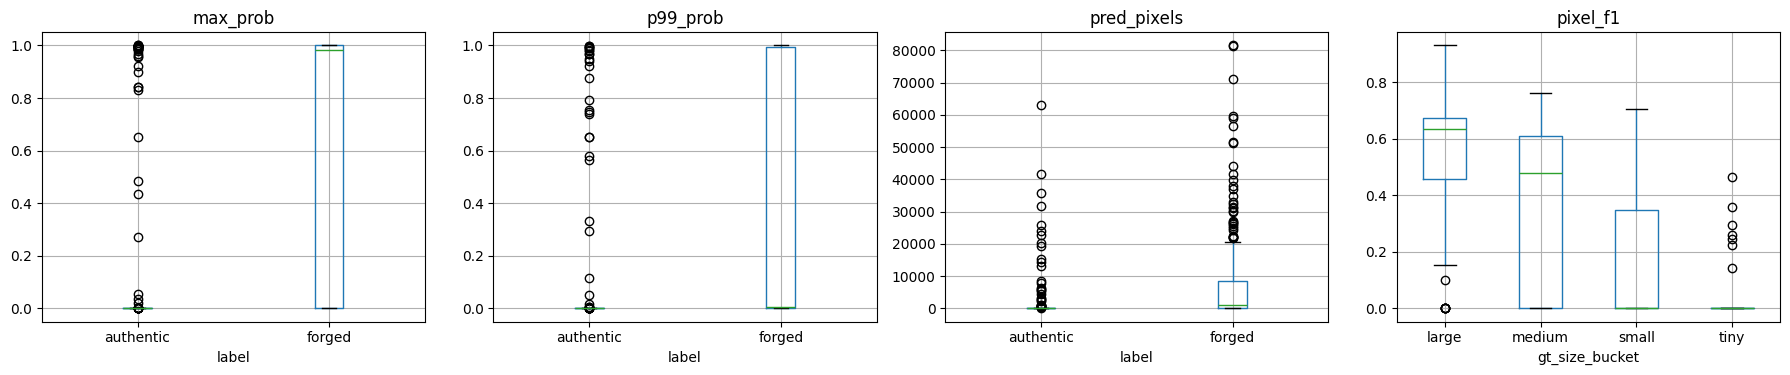

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
diagnostic_df.boxplot(column="max_prob", by="label", ax=axes[0])
diagnostic_df.boxplot(column="p99_prob", by="label", ax=axes[1])
diagnostic_df.boxplot(column="pred_pixels", by="label", ax=axes[2])
diagnostic_df.query("label == 'forged'").boxplot(column="pixel_f1", by="gt_size_bucket", ax=axes[3])
for ax in axes:
    ax.set_title(ax.get_title().replace(" by label", ""))
fig.suptitle("")
fig.tight_layout()


## Plot Examples

Authentic false positives


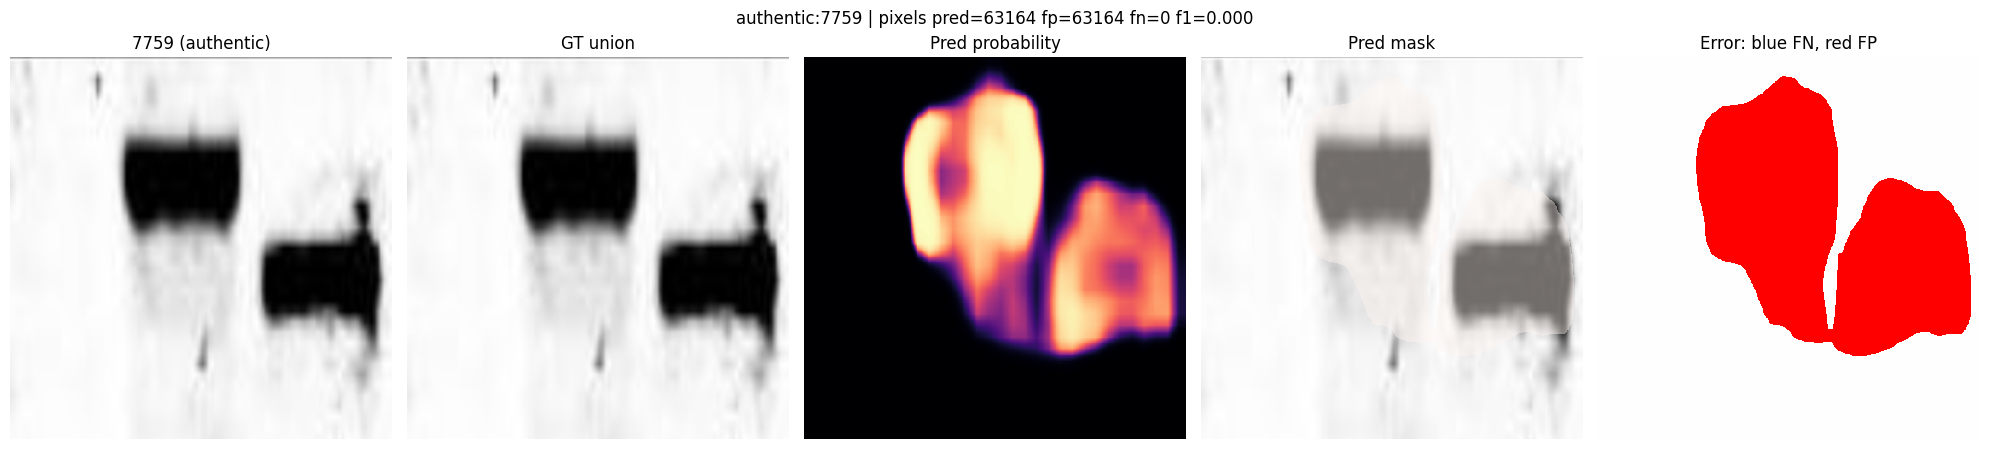

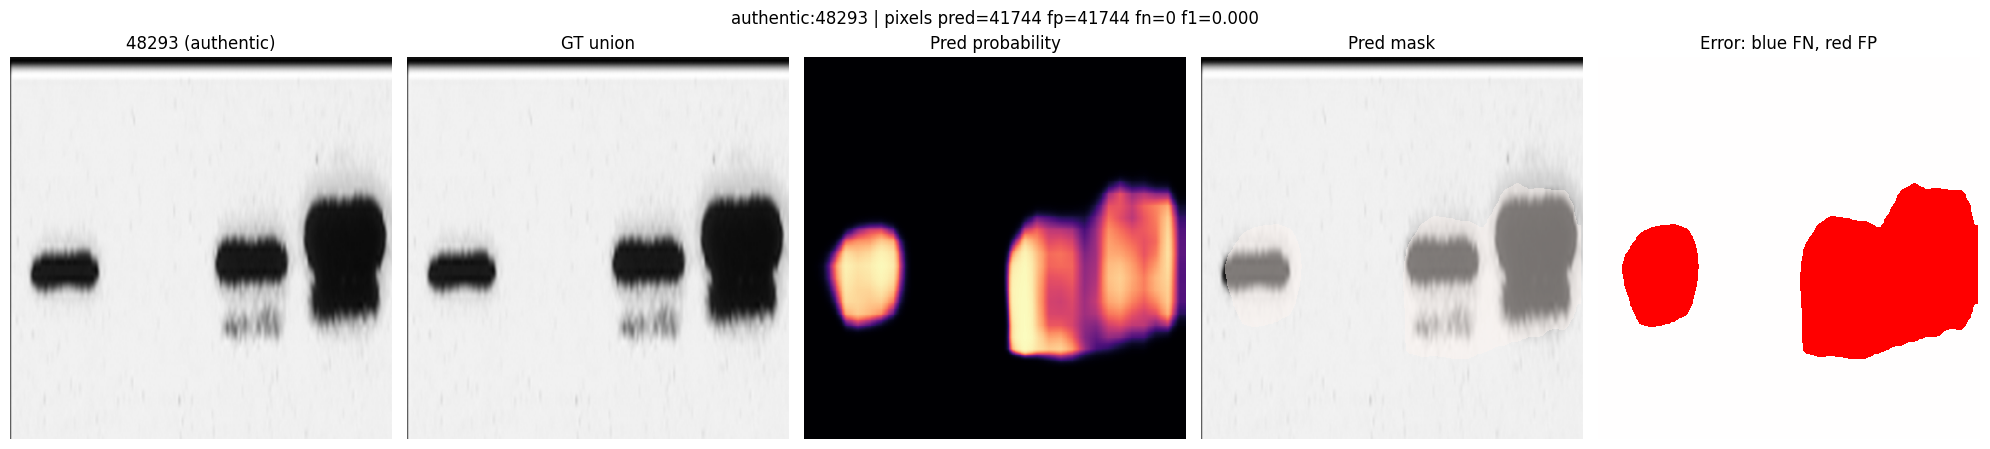

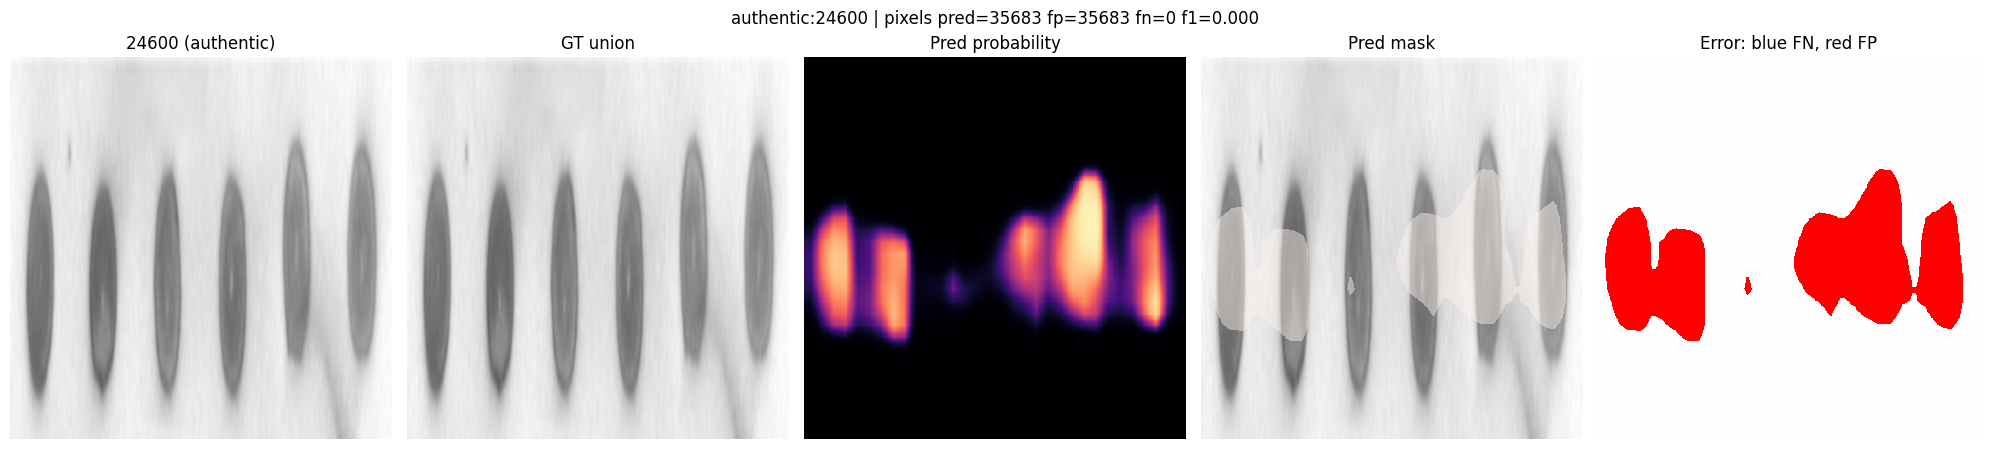

Forged misses


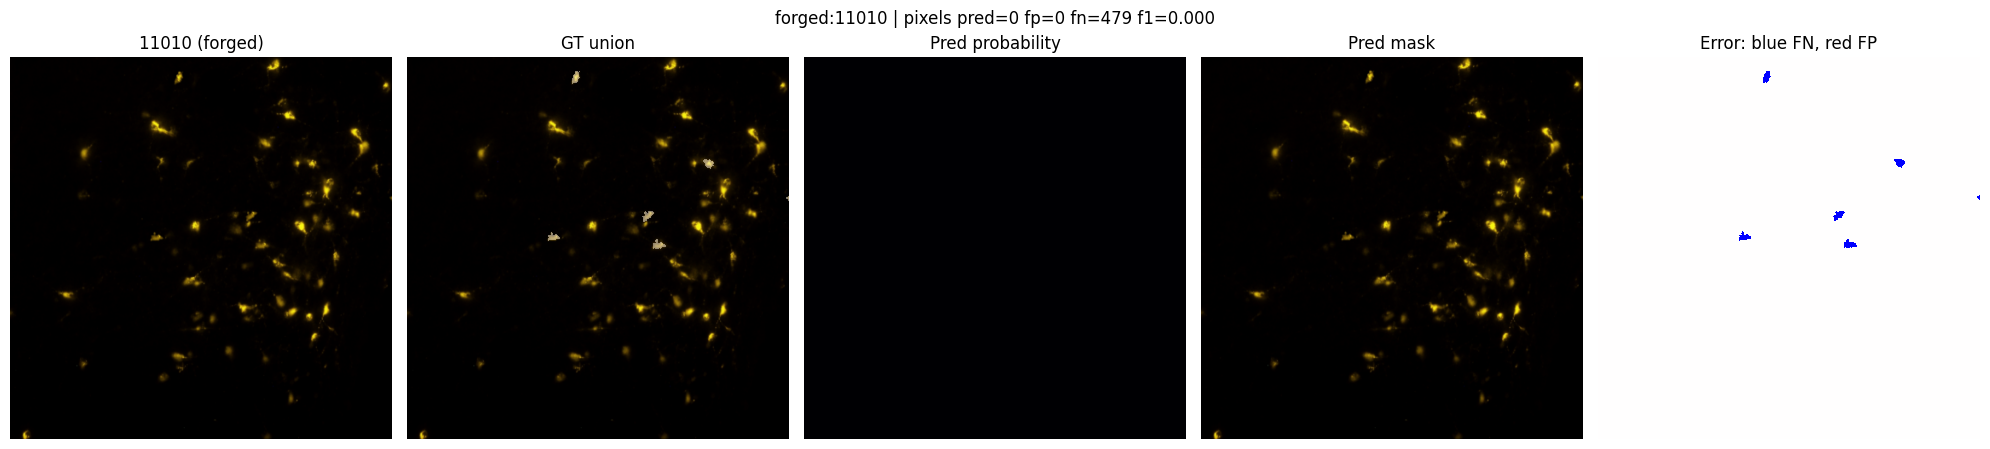

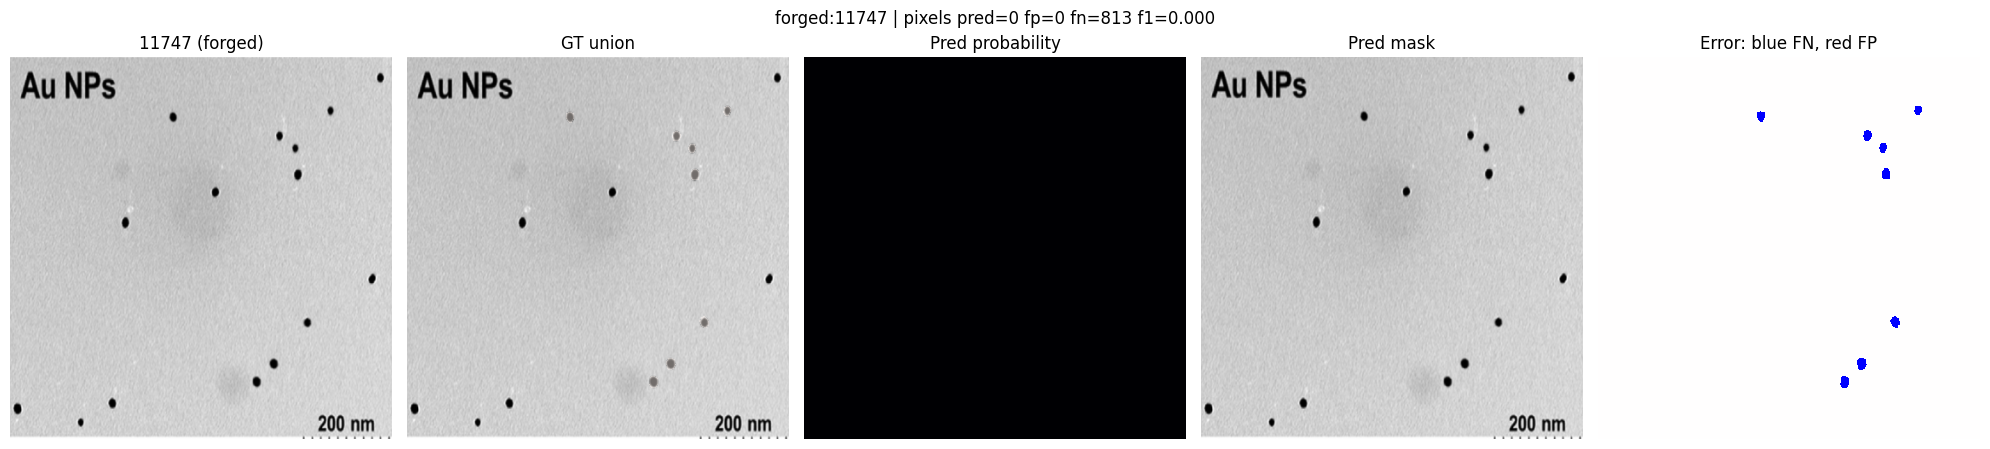

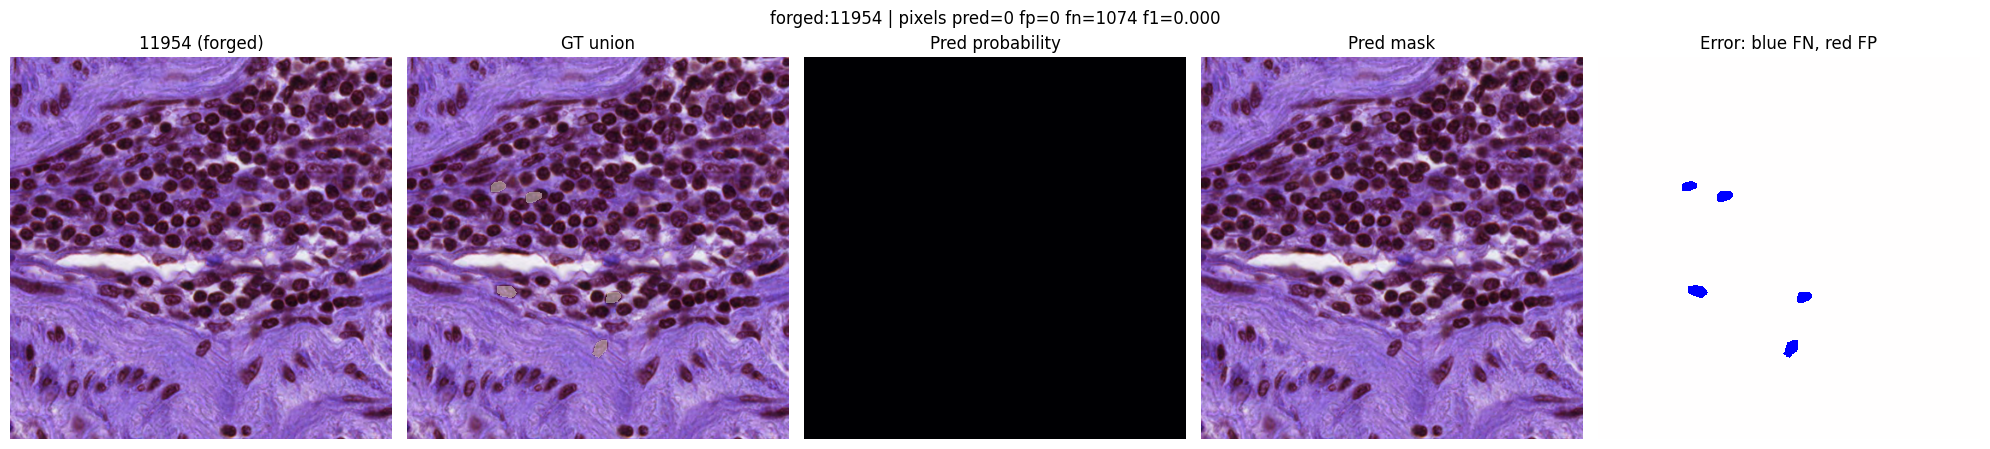

Forged successes


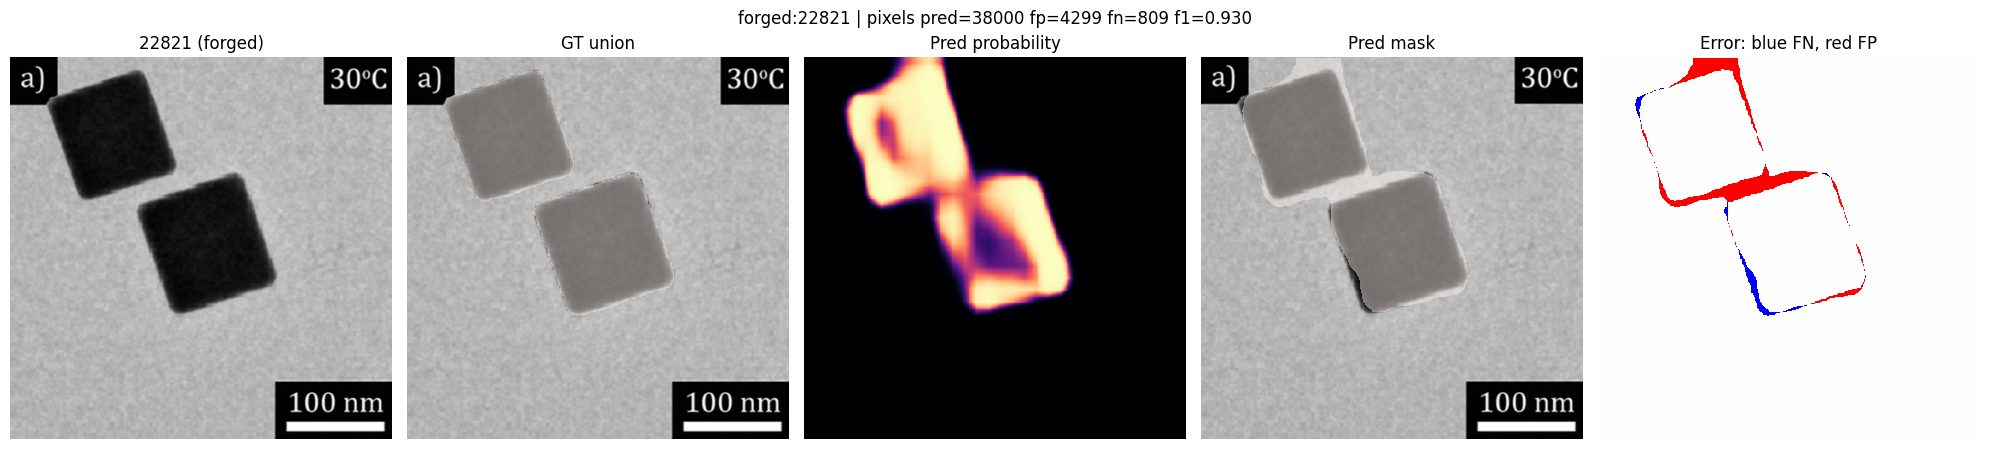

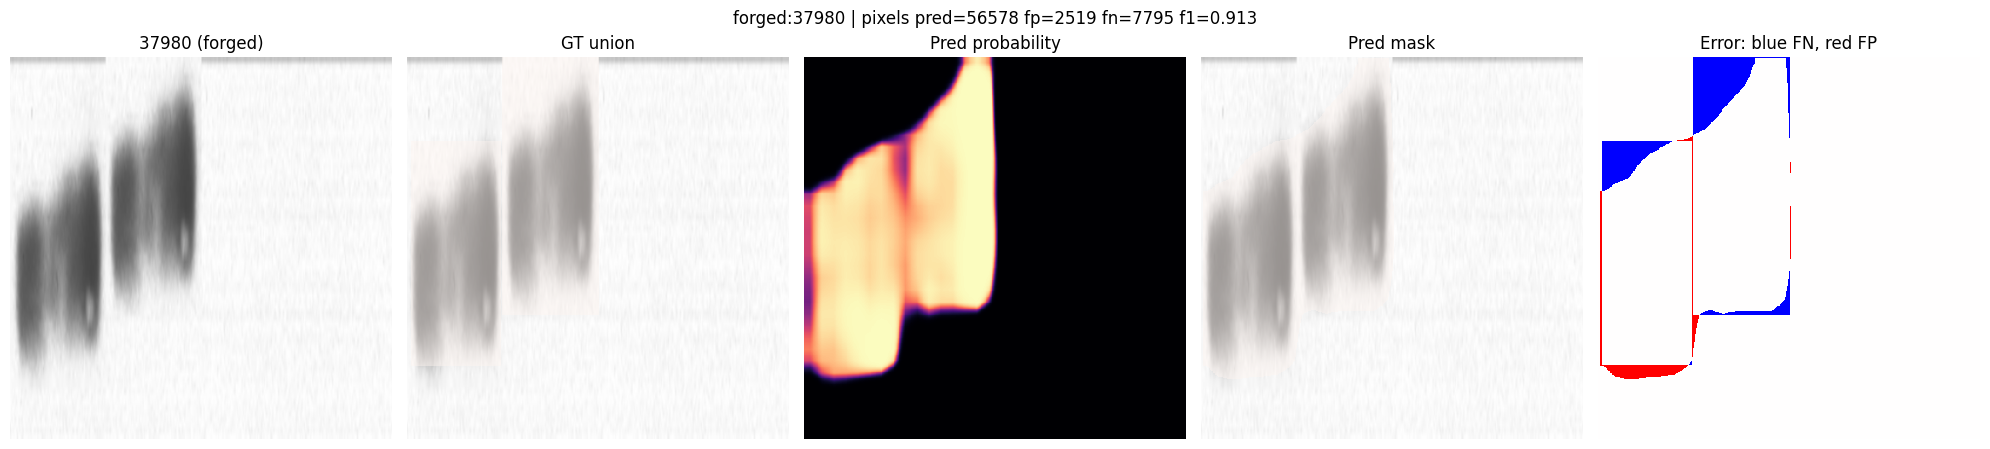

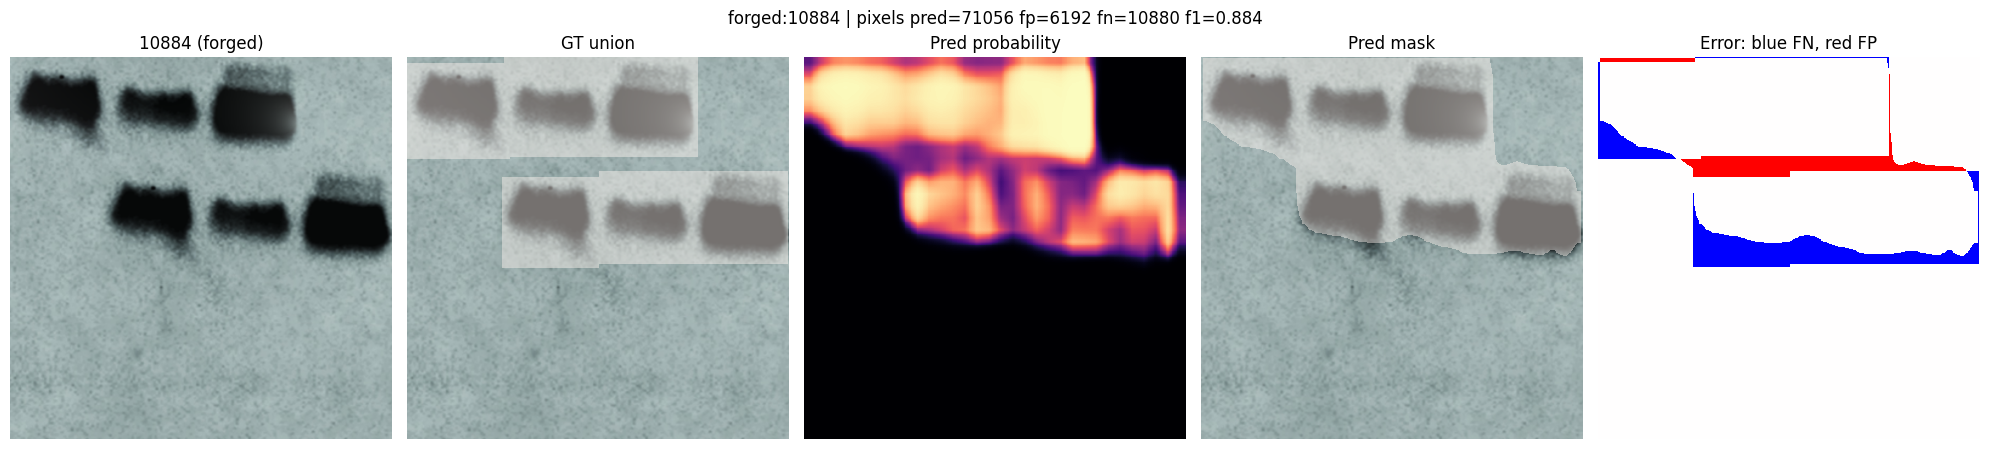

Authentic clean examples


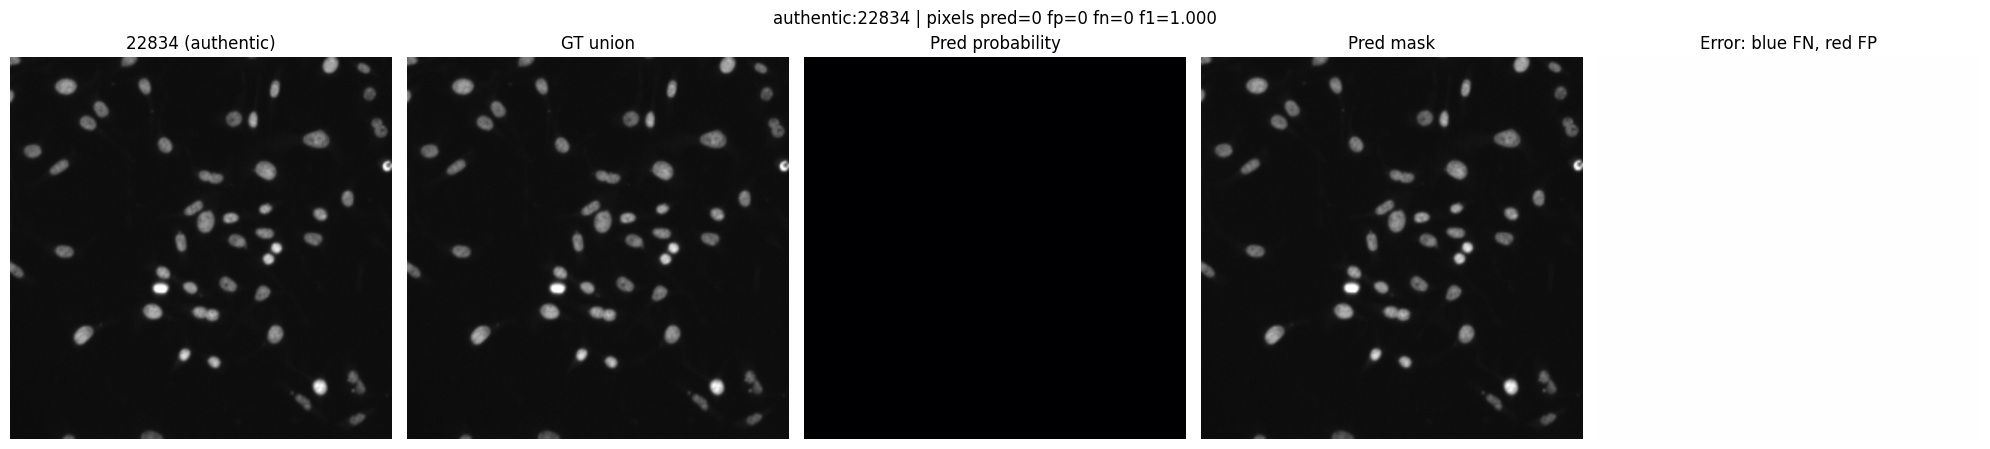

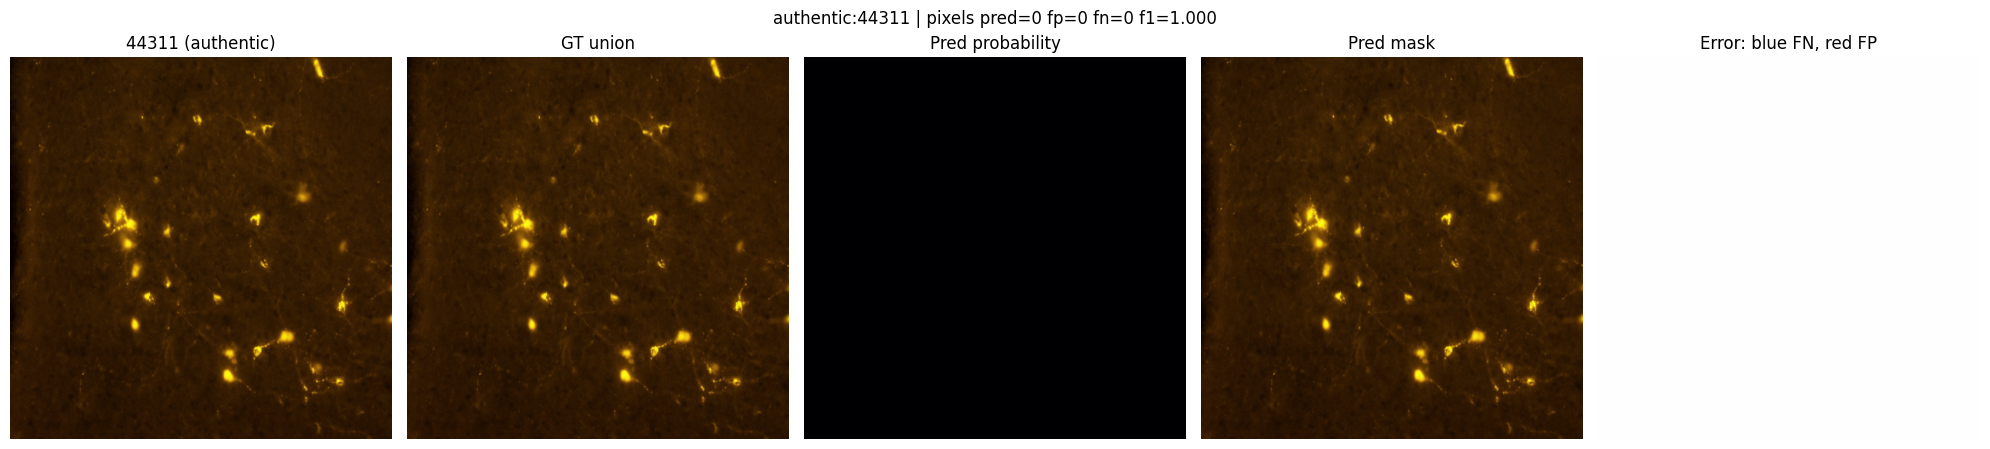

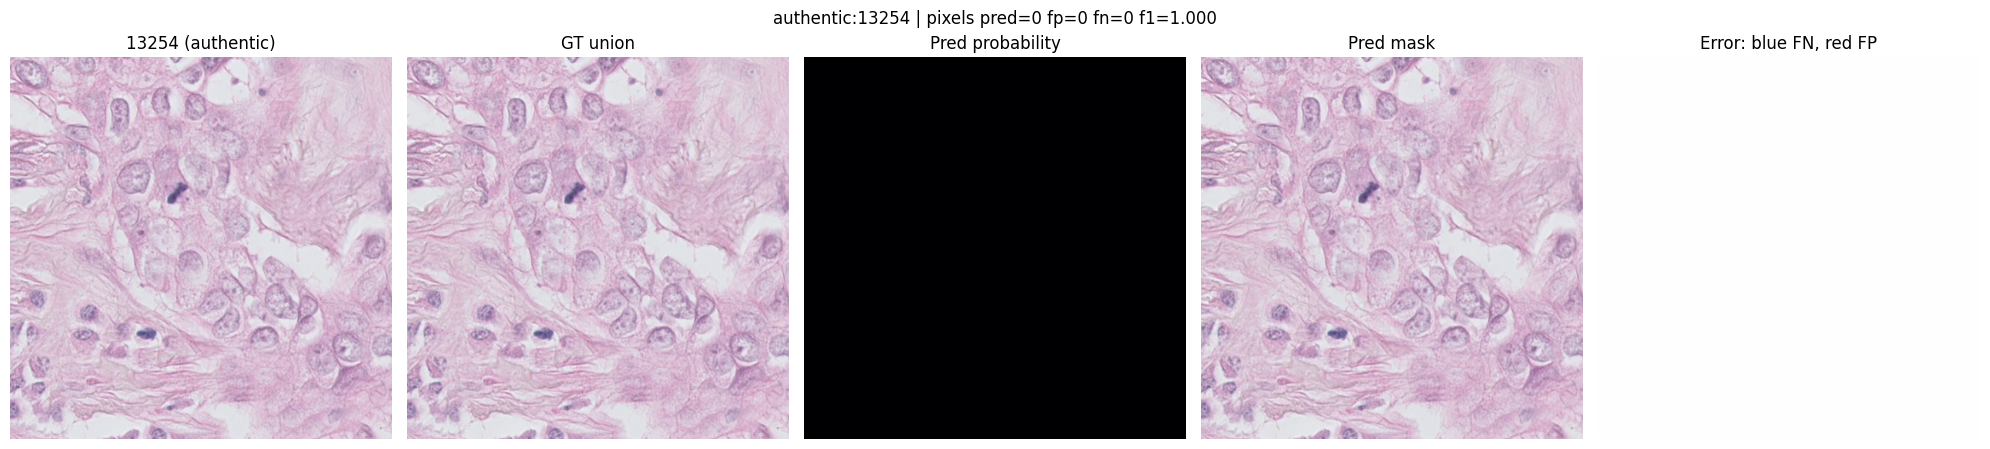

Random validation examples


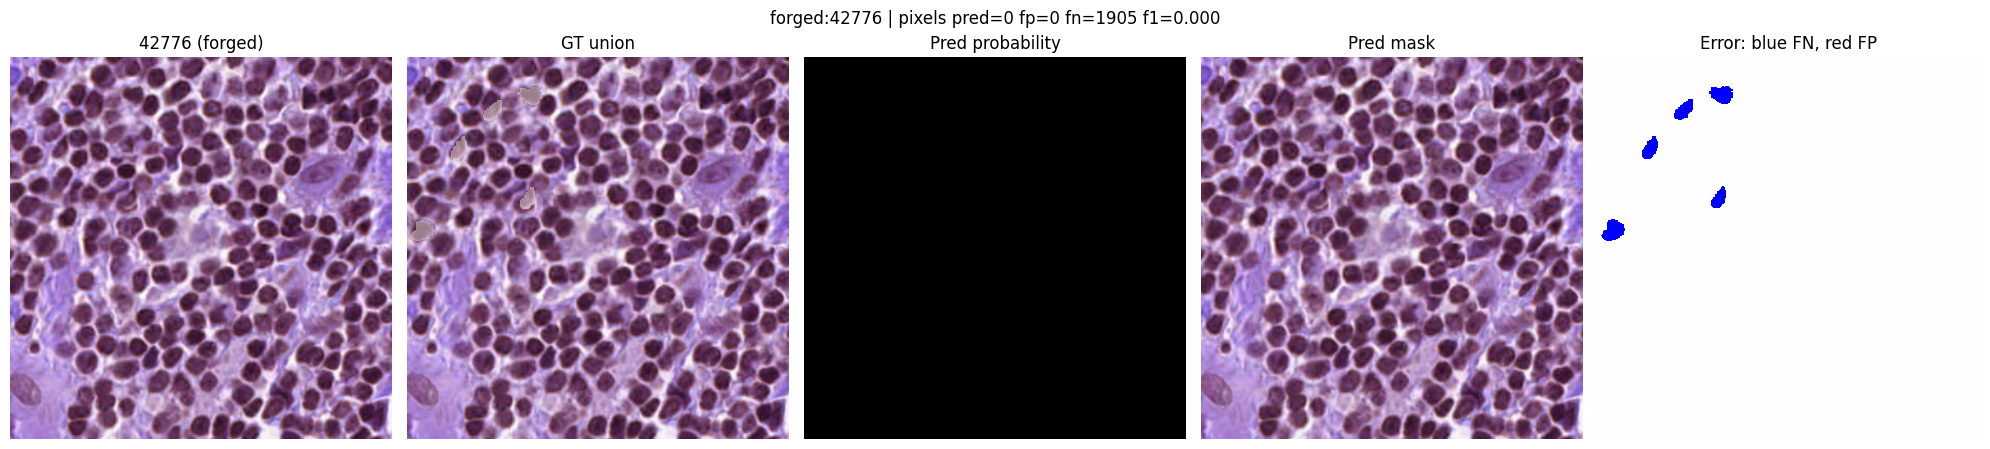

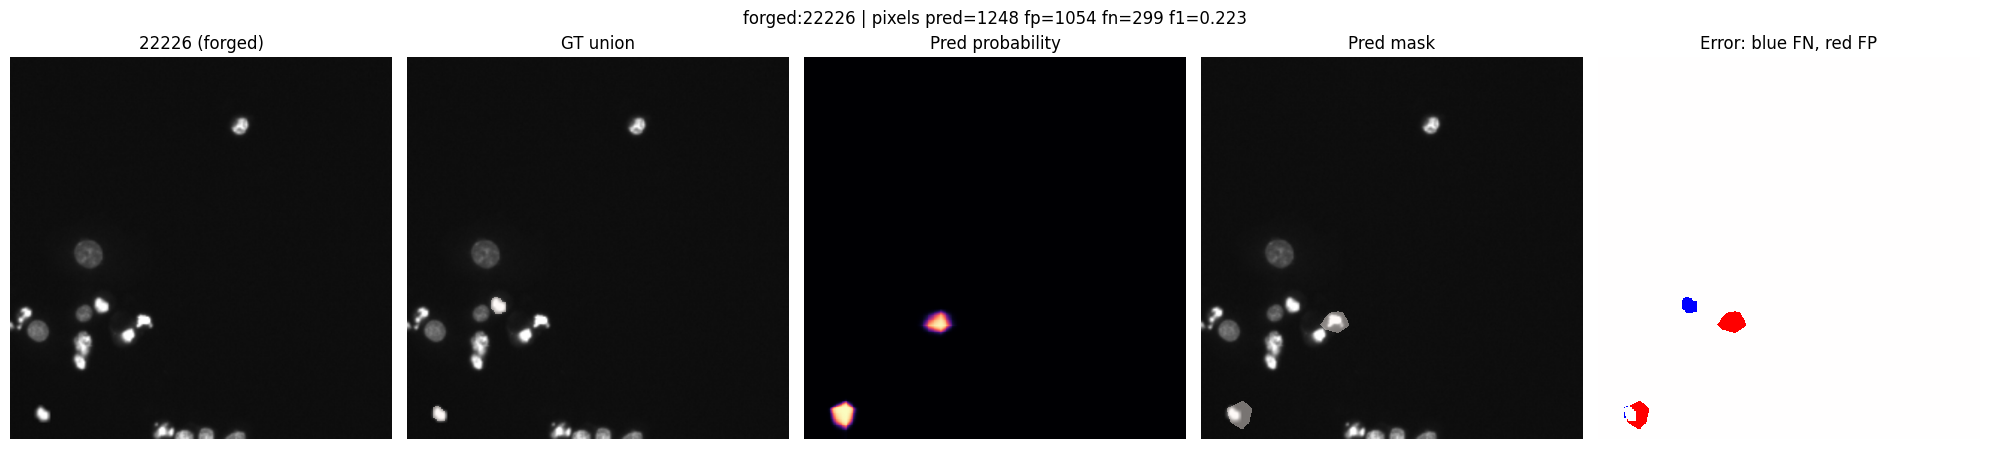

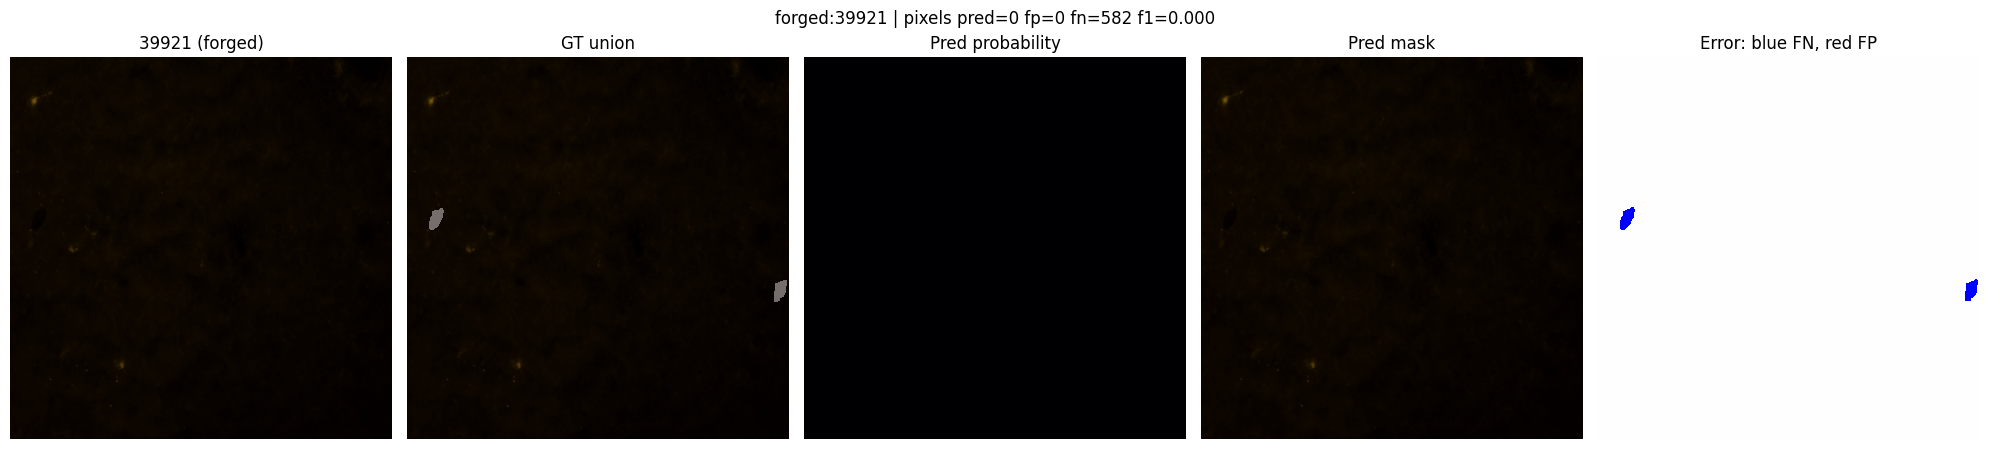

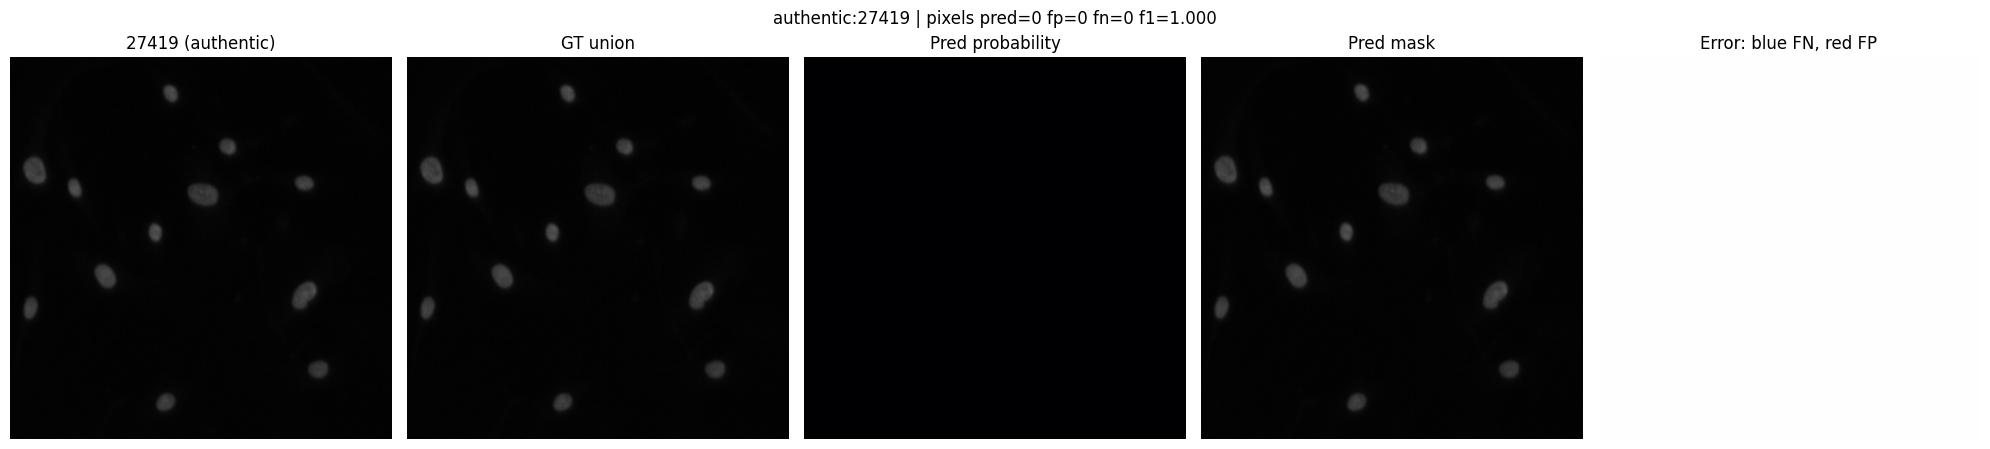

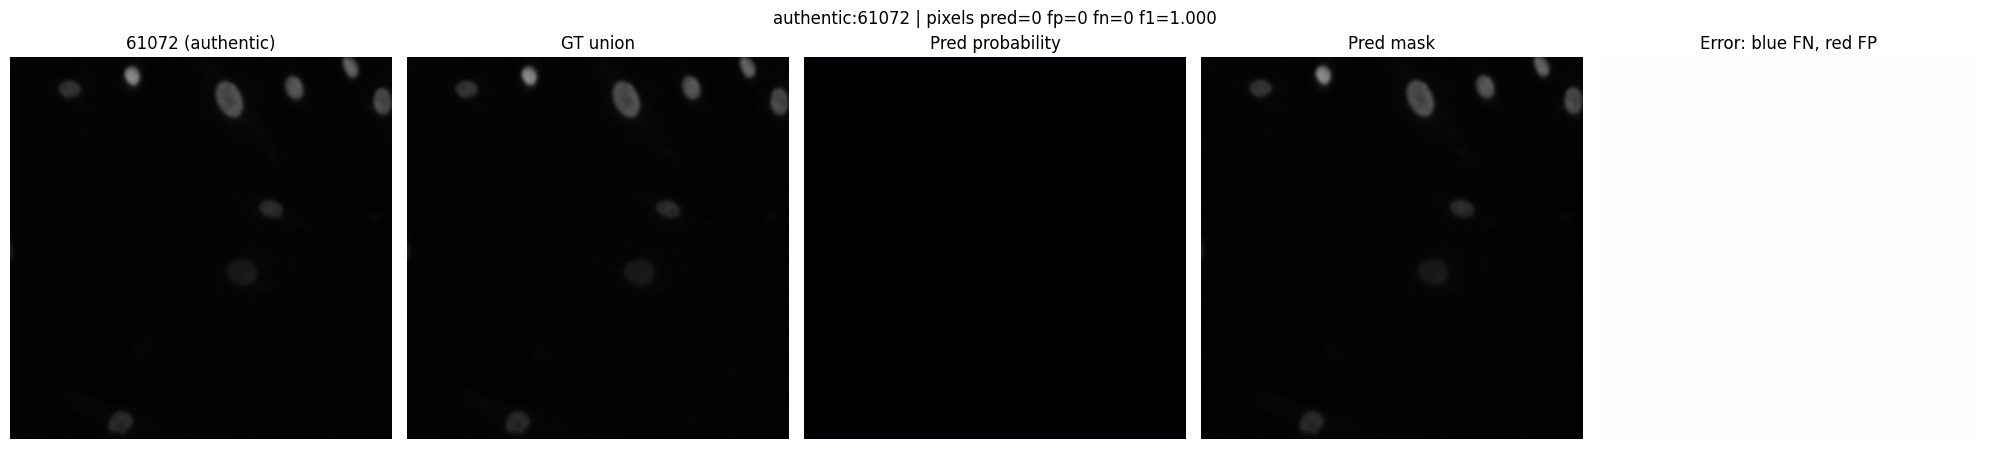

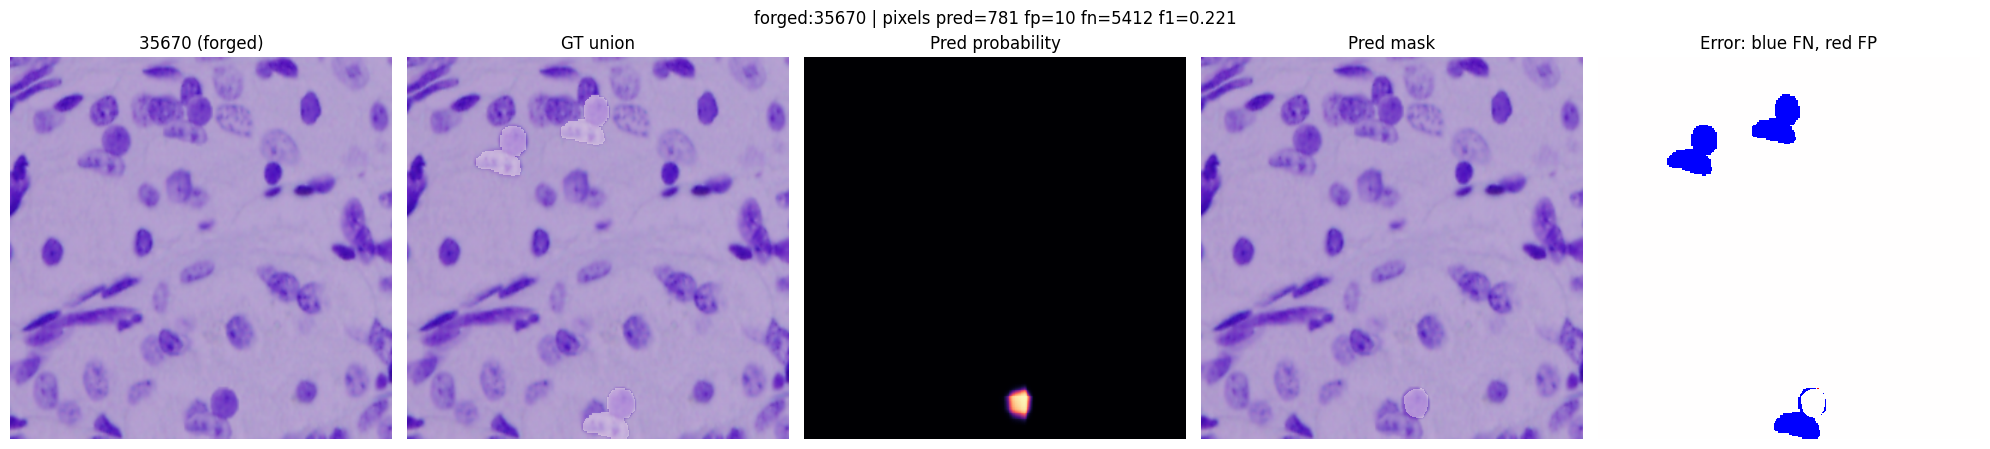

In [28]:
plotter = ForgeryDataPlotter(config.data_root)


def plot_rows(df, n=3, title=""):
    print(title)
    if len(df) == 0:
        print("No rows to plot.")
        return
    for _, row in df.head(n).iterrows():
        prediction = predictions[int(row.idx)]
        pred_bin = pred_mask_for_prediction(prediction, threshold=threshold, setting=table_setting)
        fig, axes = plotter.plot_prediction(prediction.sample, prediction.probability, pred_mask=pred_bin, threshold=threshold)
        fig.suptitle(
            f"{row.sample_id} | pixels pred={row.pred_pixels} fp={row.fp_pixels} fn={row.fn_pixels} f1={row.pixel_f1:.3f}",
            y=1.03,
        )
        plt.show()

forged_successes = diagnostic_df.query("label == 'forged' and pred_pixels > 0").sort_values(
    ["pixel_f1", "recall", "precision"], ascending=[False, False, False]
)
authentic_clean = diagnostic_df.query("label == 'authentic'").sort_values(
    ["pred_pixels", "max_prob"], ascending=[True, True]
)
random_examples = diagnostic_df.sample(n=min(6, len(diagnostic_df)), random_state=7)

plot_rows(authentic_fp, n=3, title="Authentic false positives")
plot_rows(forged_misses, n=3, title="Forged misses")
plot_rows(forged_successes, n=3, title="Forged successes")
plot_rows(authentic_clean, n=3, title="Authentic clean examples")
plot_rows(random_examples, n=6, title="Random validation examples")



## Save Diagnostics

In [29]:
output_dir = Path("einar_busternet/artifacts/results")
output_dir.mkdir(parents=True, exist_ok=True)
diagnostics_path = output_dir / "validation_diagnostics.csv"
summary_path = output_dir / "validation_diagnostics_summary.csv"
nonempty_summary_path = output_dir / "validation_diagnostics_forged_nonempty_summary.csv"
size_bucket_summary_path = output_dir / "validation_diagnostics_size_bucket_summary.csv"
diagnostic_df.to_csv(diagnostics_path, index=False)
summary.to_csv(summary_path, index=False)
forged_nonempty_summary.to_csv(nonempty_summary_path, index=False)
size_bucket_summary.to_csv(size_bucket_summary_path, index=False)
print(diagnostics_path)
print(summary_path)
print(nonempty_summary_path)
print(size_bucket_summary_path)


einar_busternet/artifacts/results/validation_diagnostics.csv
einar_busternet/artifacts/results/validation_diagnostics_summary.csv
einar_busternet/artifacts/results/validation_diagnostics_forged_nonempty_summary.csv
einar_busternet/artifacts/results/validation_diagnostics_size_bucket_summary.csv


## Cleanup GPU Memory

Run this when you are done inspecting predictions. Restarting the notebook kernel also frees everything.

In [30]:
import gc

for name in [
    "model",
    "wrapped_model",
    "val_loader",
    "predictions",
]:
    if name in globals():
        del globals()[name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print(f"CUDA allocated after cleanup: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")
    print(f"CUDA reserved after cleanup: {torch.cuda.memory_reserved() / 1024**2:.1f} MB")
else:
    print("CUDA not available")


CUDA allocated after cleanup: 415.7 MB
CUDA reserved after cleanup: 516.0 MB
